In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API key is set")
else:
    raise ValueError("Google API key is not set")

Google API key is set


In [4]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
   # other params...
)

try :
  print(model.invoke("I want to know about Langgraph ?"))
except:
  print("Something went wrong")

content='LangGraph is a library built on top of LangChain Expression Language (LCEL) that allows you to create **stateful, multi-actor applications with LLMs by modeling your logic as a graph.**\n\nThink of it as an advanced orchestration layer for your LLM agents, especially when you need complex control flow, internal memory, and the ability to loop or self-correct.\n\n## Why was LangGraph Created?\n\nTraditional LangChain chains (especially those built with LCEL) are fundamentally **Directed Acyclic Graphs (DAGs)**. This means they execute steps in a defined sequence without ever looping back to a previous step. While powerful for many tasks, this limitation becomes apparent when building more sophisticated "agentic" behaviors:\n\n1.  **Iterative Reasoning/Self-Correction:** An agent might try something, fail, reflect on the failure, and then try again with a revised approach. This requires looping.\n2.  **Tool Use with Feedback Loops:** An agent calls a tool, gets a result, and the

In [42]:
from typing import TypedDict, List, Annotated
from operator import add

class graph_schema(TypedDict):
    messages_manual: List
    #Using Reducers in Langgraph
    messages_auto: Annotated[List,add] # This is something where messages are handled automatically using reducers and Annotated is a data type, Here we have Annotated type of List, with add arg(stating that the list will be adding new items)


### Messages
Messages are of various types
1) AI Message: The Output of LLM
2)Human Message: Input Query
3)System Message : To set the tone of LLM(you are a expert in this field Computer Science)
4)Tool Message : The response we get from a tool or function

In [43]:
from langchain_core.messages import AIMessage

def create_post(state: graph_schema)-> graph_schema:

    messages_manual = state['messages_manual']
    response_manual = model.invoke(messages_manual).content # To get only the content section from LLM(Check cell 2 run, we will content,etc metadata)
    response_manual_ai = AIMessage(content=response_manual) # in invoke method, behind the scenes we will have HumanMessage as a Message, Now the response we get it AI Message with Metadata, To differentiate the messages we need to use AIMessage, To save tokens, we refer only content and wrap it in AIMessage, removing rest of metadata.
    state['messages_manual'].append(response_manual_ai) # equivalent to state['messages_manual'] = messages_manual + [response_manual_ai]

    messages_auto = state['messages_auto']
    response_auto = model.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state['messages_auto']=[response_auto_ai]

    return state

def curate_post(state:graph_schema)->graph_schema:
    
    messages_manual = state['messages_manual']
    response_manual = model.invoke(messages_manual).content # To get only the content section from LLM(Check cell 2 run, we will content,etc metadata)
    response_manual_ai = AIMessage(content=response_manual) # in invoke method, behind the scenes we will have HumanMessage as a Message, Now the response we get it AI Message with Metadata, To differentiate the messages we need to use AIMessage, To save tokens, we refer only content and wrap it in AIMessage, removing rest of metadata.
    state['messages_manual'].append(response_manual_ai) # equivalent to state['messages_manual'] = messages_manual + [response_manual_ai]

    messages_auto = state['messages_auto']
    response_auto = model.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state['messages_auto']=[response_auto_ai]

    return state

In [44]:
from langgraph.graph import StateGraph, START, END 

graph = StateGraph(graph_schema)

graph.add_node("create_post",create_post)
graph.add_node("curate_post",curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

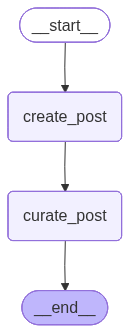

In [45]:
from IPython.display import Image, display

message_graph=graph.compile()

Image(message_graph.get_graph().draw_mermaid_png())

In [46]:
from langchain_core.messages import HumanMessage

message_graph.invoke(
    {"messages_manual":[HumanMessage(content="The importance of data privacy in the digital age")],
     "messages_auto":[HumanMessage(content="The importance of data privacy in the digital age")]}
    )

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 13.535608213s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT